In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
import healpix_geo
import sys
sys.path.append("..")
from healpix_analyse.make_rectangle import make_healpix_rectangle_from_lonlat, intersect_with_nested_cell_ids
from healpix_analyse.resample import resample_to_latlon_grid
from healpix_analyse.ps import ps

## Data from tina notebook's S2

In [10]:
ds = xr.open_zarr("/home/jovyan/s2_reflectance_20.zarr")
ds

<xarray.Dataset> Size: 168MB
Dimensions:   (cells: 4194304)
Coordinates:
    cell_ids  (cells) uint64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
Dimensions without coordinates: cells
Data variables:
    b02       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b03       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b04       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>
    b08       (cells) float64 34MB dask.array<chunksize=(1048576,), meta=np.ndarray>

In [11]:
# Define the bounding box for the rectangle (lon_min, lat_min, lon_max, lat_max)
lon_min, lon_max = 2.07, 2.13
lat_min, lat_max = 48.55, 48.6

# Define the HEALPix grid parameters
level = 20
ellipsoid = "WGS84"

In [12]:
cell_ids_2D_array = make_healpix_rectangle_from_lonlat(bbox=(lon_min, lat_min, lon_max, lat_max), 
                                                       level=level, 
                                                       ellipsoid=ellipsoid)

lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids_2D_array.flatten(), level, ellipsoid=ellipsoid)

print(cell_ids_2D_array.shape)
print(lon.shape, lat.shape)
print(ds["cells"].shape)
print(ds.cell_ids.shape)

(1051, 609)
(640059,) (640059,)
(4194304,)
(4194304,)


In [13]:
_, nested_inds, _ = intersect_with_nested_cell_ids(
    cell_ids_2D_array, 
    nested_cell_ids=ds.cell_ids, 
    level=level)

In [14]:
data = ds.isel(cells=nested_inds)["b02"].values

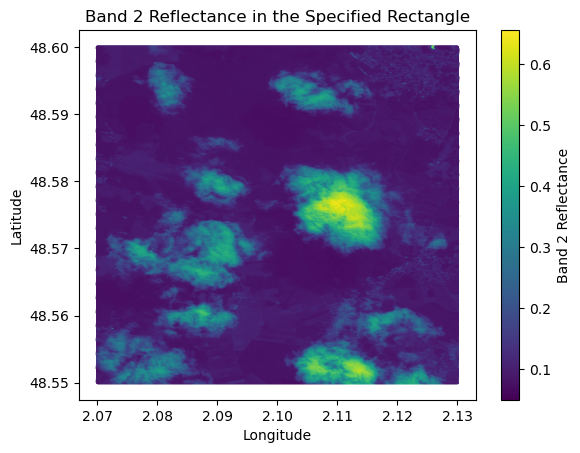

In [15]:
plt.scatter(lon, lat, c=data, s=1)
plt.colorbar(label="Band 2 Reflectance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Band 2 Reflectance in the Specified Rectangle")
plt.show()

In [16]:
# reshape lat, lon, data as 2D array like cell_ids_2D_array
lat = lat.reshape(cell_ids_2D_array.shape)
lon = lon.reshape(cell_ids_2D_array.shape)
data = data.reshape(cell_ids_2D_array.shape)

In [17]:
data_resampled = resample_to_latlon_grid(lat, lon, data, method='cubic')

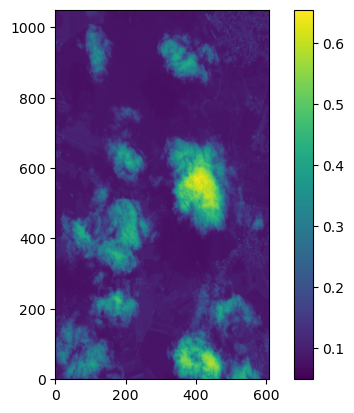

In [18]:
plt.imshow(data_resampled, origin="lower")
plt.colorbar()
plt.show()

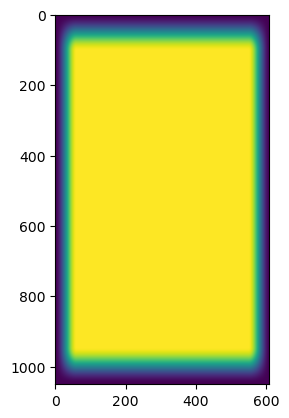

In [19]:
alpha = .2

apodizing_window = tukey(data_resampled.shape[0], alpha=alpha)[:,None] * tukey(data_resampled.shape[1], alpha=alpha)[None,:]

plt.imshow(apodizing_window)

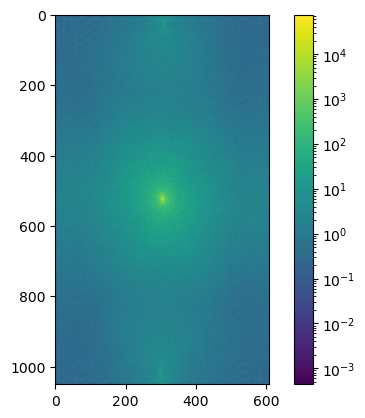

In [20]:
plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(apodizing_window * data_resampled))), norm='log')
plt.colorbar()
plt.show()

In [21]:
freqs, spectrum = ps(apodizing_window * data_resampled)

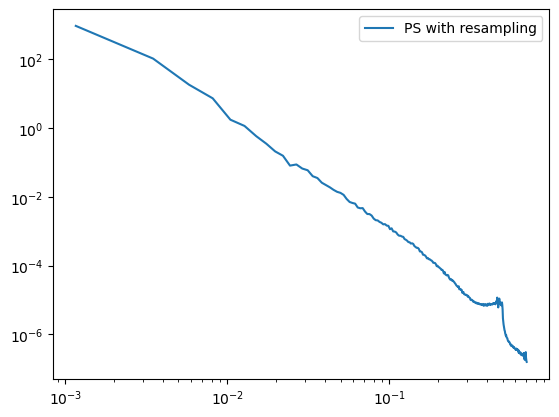

In [22]:
plt.plot(freqs, spectrum, label='PS with resampling')
plt.yscale('log')
plt.xscale('log')
plt.legend()

## Test with S2 l2a

In [57]:
ds = xr.open_zarr("/home/jovyan/s2_l2a_reflectance_20.zarr", group="measurements/reflectance/20")
ds

<xarray.Dataset> Size: 73MB
Dimensions:   (cells: 1835008)
Dimensions without coordinates: cells
Data variables:
    b02       (cells) float64 15MB dask.array<chunksize=(262144,), meta=np.ndarray>
    b03       (cells) float64 15MB dask.array<chunksize=(262144,), meta=np.ndarray>
    b04       (cells) float64 15MB dask.array<chunksize=(262144,), meta=np.ndarray>
    b08       (cells) float64 15MB dask.array<chunksize=(262144,), meta=np.ndarray>
    cell_ids  (cells) uint64 15MB dask.array<chunksize=(262144,), meta=np.ndarray>
Attributes:
    zarr_conventions:  [{'uuid': '7b255807-140c-42ca-97f6-7a1cfecdbc38', 'nam...
    dggs:              {'name': 'healpix', 'refinement_level': 20, 'indexing_...

In [64]:
# Define the bounding box for the rectangle (lon_min, lat_min, lon_max, lat_max)
lon_min, lon_max = 1.995, 2.025
lat_min, lat_max = 48.62, 48.66

# Define the HEALPix grid parameters
level = 20
ellipsoid = "WGS84"

In [65]:
cell_ids_2D_array = make_healpix_rectangle_from_lonlat(bbox=(lon_min, lat_min, lon_max, lat_max), 
                                                       level=level, 
                                                       ellipsoid=ellipsoid)

lon, lat = healpix_geo.ring.healpix_to_lonlat(cell_ids_2D_array.flatten(), level, ellipsoid=ellipsoid)

print(cell_ids_2D_array.shape)
print(lon.shape, lat.shape)
print(ds["cells"].shape)
print(ds.cell_ids.shape)

(841, 305)
(256505,) (256505,)
(1835008,)
(1835008,)


In [66]:
_, nested_inds, _ = intersect_with_nested_cell_ids(
    cell_ids_2D_array, 
    nested_cell_ids=ds.cell_ids, 
    level=level)

In [67]:
data = ds.isel(cells=nested_inds)["b02"].values

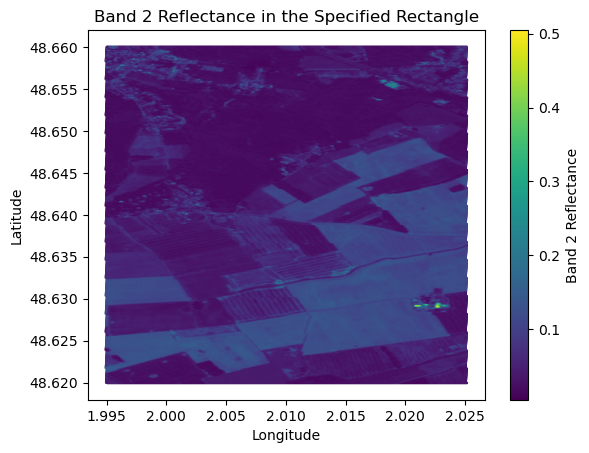

In [68]:
plt.scatter(lon, lat, c=data, s=1)
plt.colorbar(label="Band 2 Reflectance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Band 2 Reflectance in the Specified Rectangle")
plt.show()

In [69]:
# reshape lat, lon, data as 2D array like cell_ids_2D_array
lat = lat.reshape(cell_ids_2D_array.shape)
lon = lon.reshape(cell_ids_2D_array.shape)
data = data.reshape(cell_ids_2D_array.shape)

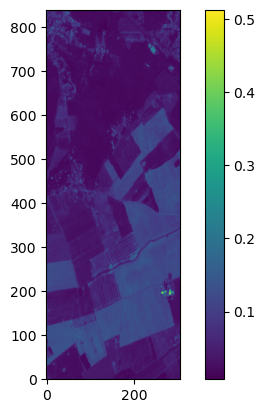

In [70]:
data_resampled = resample_to_latlon_grid(lat, lon, data, method='cubic')

plt.imshow(data_resampled, origin="lower")
plt.colorbar()
plt.show()

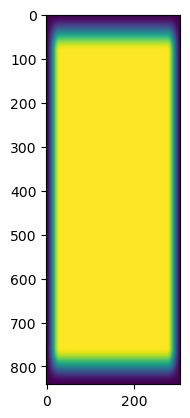

In [71]:
alpha = .2

apodizing_window = tukey(data_resampled.shape[0], alpha=alpha)[:,None] * tukey(data_resampled.shape[1], alpha=alpha)[None,:]

plt.imshow(apodizing_window)

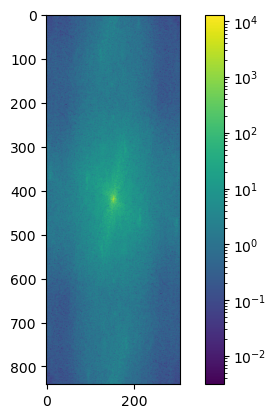

In [72]:
plt.imshow(np.fft.fftshift(np.abs(np.fft.fft2(apodizing_window * data_resampled))), norm='log')
plt.colorbar()
plt.show()

In [73]:
freqs, spectrum = ps(apodizing_window * data_resampled)

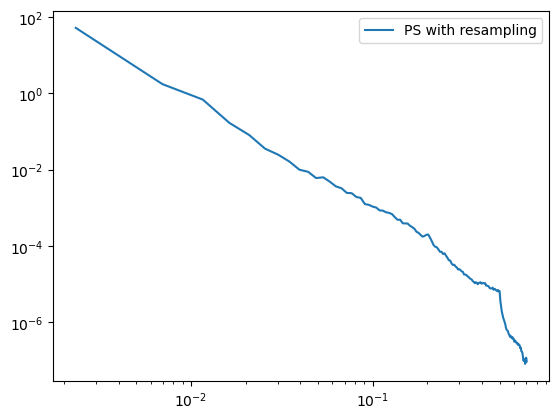

In [74]:
plt.plot(freqs, spectrum, label='PS with resampling')
plt.yscale('log')
plt.xscale('log')
plt.legend()